In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [5]:
df = pd.read_csv("stores_sales_forecasting.csv", encoding='latin-1')

In [6]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   str    
 2   Order Date     2121 non-null   str    
 3   Ship Date      2121 non-null   str    
 4   Ship Mode      2121 non-null   str    
 5   Customer ID    2121 non-null   str    
 6   Customer Name  2121 non-null   str    
 7   Segment        2121 non-null   str    
 8   Country        2121 non-null   str    
 9   City           2121 non-null   str    
 10  State          2121 non-null   str    
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   str    
 13  Product ID     2121 non-null   str    
 14  Category       2121 non-null   str    
 15  Sub-Category   2121 non-null   str    
 16  Product Name   2121 non-null   str    
 17  Sales          2121 non-null   float64
 18  Quantity       2121

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [9]:
df = df.drop_duplicates()

In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [11]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Day'] = df['Order Date'].dt.day
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [12]:
print("\nCleaned Dataset Preview:")
print(df.head())


Cleaned Dataset Preview:
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
3       6  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   
4      11  CA-2014-115812 2014-06-09 2014-06-14  Standard Class    BH-11710   

     Customer Name   Segment        Country             City  ...  \
0      Claire Gute  Consumer  United States        Henderson  ...   
1      Claire Gute  Consumer  United States        Henderson  ...   
2   Sean O'Donnell  Consumer  United States  Fort Lauderdale  ...   
3  Brosina Hoffman  Consumer  United States      Los Angeles  ...   
4  Brosina Hoffman  Consumer  United States      Los Angeles  ...   

  Sub-Category                                       Product Name      Sales  \
0   

In [13]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100

In [14]:
print("\n================ BUSINESS SUMMARY ================")
print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Profit Margin %:", round(profit_margin, 2))


================ BUSINESS SUMMARY ================
Total Sales: 741999.8
Total Profit: 18451.27
Profit Margin %: 2.49


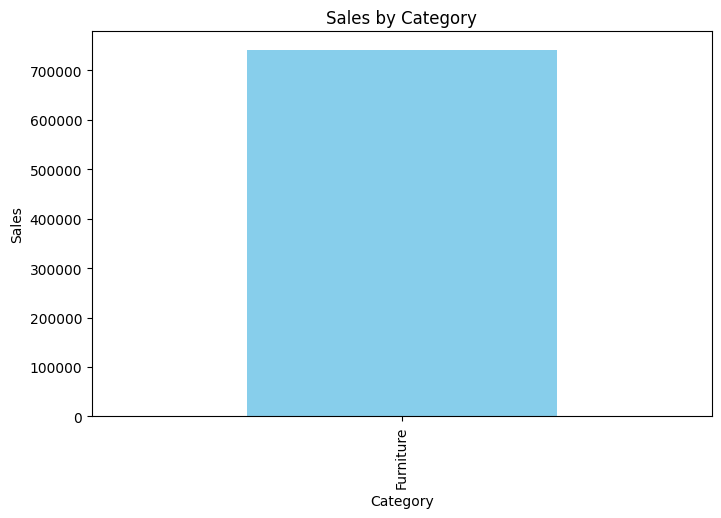

In [15]:
plt.figure(figsize=(8,5))
df.groupby('Category')['Sales'].sum().plot(kind='bar', color='skyblue')
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

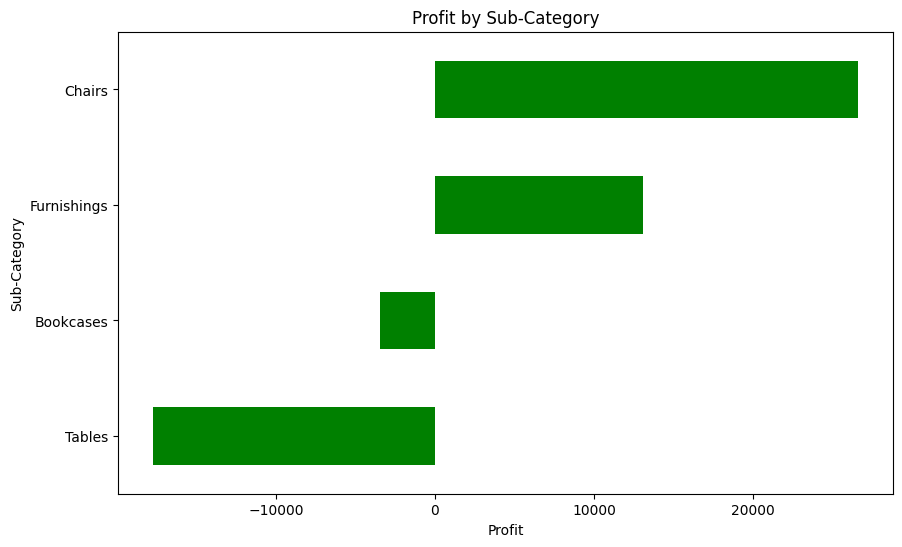

In [16]:
plt.figure(figsize=(10,6))
df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh', color='green')
plt.title("Profit by Sub-Category")
plt.xlabel("Profit")
plt.show()

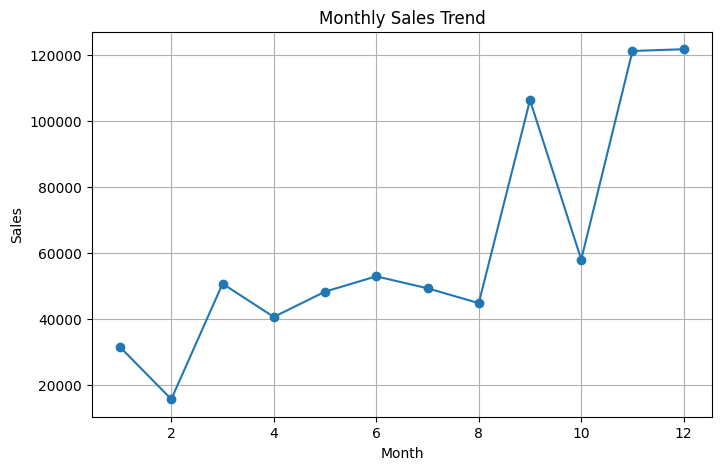

In [17]:
plt.figure(figsize=(8,5))
df.groupby('Order Month')['Sales'].sum().plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

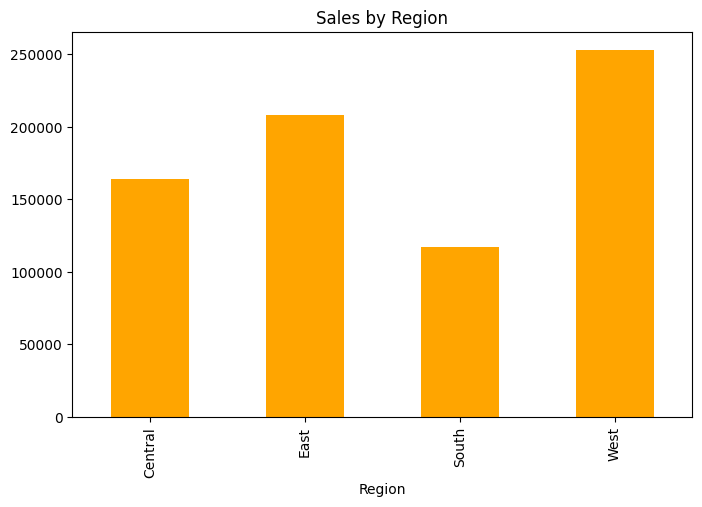

In [18]:
plt.figure(figsize=(8,5))
df.groupby('Region')['Sales'].sum().plot(kind='bar', color='orange')
plt.title("Sales by Region")
plt.show()

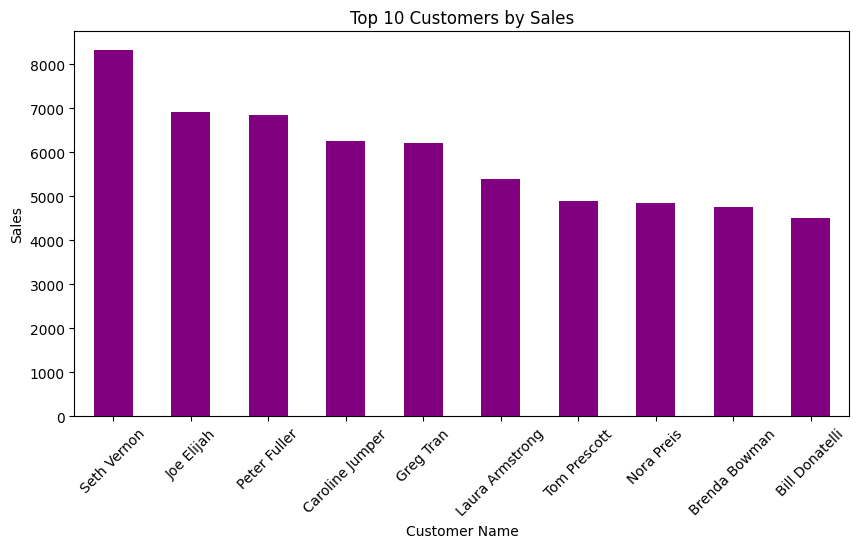

In [19]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar', color='purple')
plt.title("Top 10 Customers by Sales")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

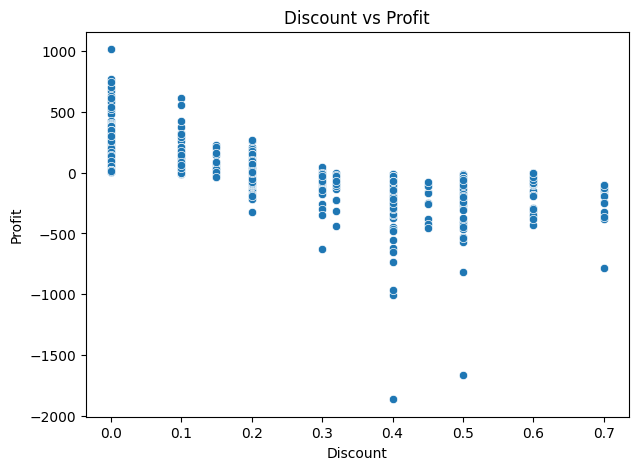

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title("Discount vs Profit")
plt.show()

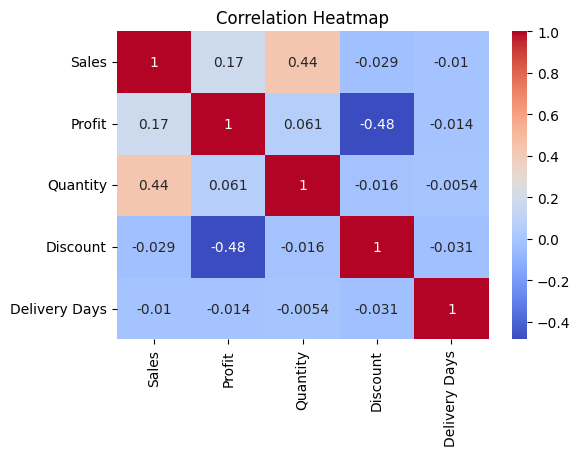

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales','Profit','Quantity','Discount','Delivery Days']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [22]:
features = df[['Sales', 'Quantity', 'Discount']]
target = df['Profit']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_pred = model.predict(X_test)

In [24]:
print("\n================ ML MODEL RESULTS ================")
print("R2 Score:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 3))


================ ML MODEL RESULTS ================
R2 Score: 0.286
MAE: 62.694


In [25]:
sample = np.array([[500, 5, 0.2]])
pred_profit = model.predict(sample)

print("\nSample Prediction Profit:", pred_profit[0])


Sample Prediction Profit: 5.099047132316343


c:\Users\Dikshya Thapa\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


This project focuses on analyzing a Superstore sales dataset to gain meaningful business insights using Python data analysis techniques. The dataset contains information about customer orders, sales, profit, discounts, product categories, regions, and shipping details. The data was first cleaned by removing duplicates, handling date formats, and creating new features such as order year, order month, and delivery duration. After preprocessing, exploratory data analysis (EDA) was performed to understand sales and profit patterns across different categories, sub-categories, regions, and customers. Visualizations were used to identify trends such as monthly sales variation, top-performing customers, and the impact of discounts on profit. A correlation analysis was also conducted to study relationships between numerical variables like sales, profit, quantity, and discount. Finally, a simple machine learning model using Linear Regression was built to predict profit based on sales, quantity, and discount. Overall, the project helps in understanding business performance, identifying profitable segments, and making data-driven decisions for improving sales strategy.